In [ ]:
#Importing the dataset
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/Datasets/MeTooHate.csv'
import pandas as pd
df = pd.read_csv(CSV_PATH, low_memory=False)
print("Rows:", len(df), "Cols: ", df.shape[1])
print('Columns:', list(df.columns)[:20])
df.head(3)

Rows: 807174 Cols:  10
Columns: ['status_id', 'text', 'created_at', 'favorite_count', 'retweet_count', 'location', 'followers_count', 'friends_count', 'statuses_count', 'category']


,status_id,text,created_at,favorite_count,retweet_count,location,followers_count,friends_count,statuses_count,category
0,1046207313588236290,"Entitled, obnoxious, defensive, lying weasel. ...",2018-09-30T01:17:15Z,5,1,"McAllen, TX",2253,2303,23856,0
1,1046207328113086464,Thank you and for what you did for the women...,2018-09-30T01:17:19Z,5,2,"Tampa, FL",2559,4989,19889,0
2,1046207329589493760,Knitting (s) &amp; getting ready for January 1...,2018-09-30T01:17:19Z,0,0,"St Cloud, MN",16,300,9,0


In [ ]:
# DATASET STATS BEFORE CLEANING

total_rows = len(df)
missing_text = df['text'].isna().sum()
duplicates_raw = df['text'].duplicated().sum()
empty_strings = (df['text'].astype(str).str.strip().str.len() == 0).sum()

print("==== BEFORE CLEANING ====")
print("Total rows:                 ", total_rows)
print("Missing text values:        ", missing_text)
print("Duplicate text rows:        ", duplicates_raw)
print("Empty text rows:            ", empty_strings)

==== BEFORE CLEANING ====
Total rows:                  807174
Missing text values:         3536
Duplicate text rows:         111998
Empty text rows:             226


In [ ]:
# DATA CLEANING AND PREPROCESSING
import re
def fix_emojis(text):
  if pd.isna(text):
    return ""
  try:
    return str(text).encode("ISO-8859-1").decode("utf-8")
  except:
    return str(text)
TEXT_COL = 'text'
df['raw_text'] = df[TEXT_COL].apply(fix_emojis).astype(str).str.strip()
df = df.dropna(subset=['raw_text']) # drops rows with missing text
df = df[df['raw_text'].str.len()>0] # drops rows with length 0
df = df.drop_duplicates(subset=['raw_text']).reset_index(drop=True) # drops duplicate entries

In [ ]:
# DATASET STATS AFTER CLEANING

print("==== AFTER CLEANING ====")
print("Remaining rows:             ", len(df))

# Location stats
if 'location' in df.columns:
    loc_unknown = (df['location'] == "Unknown").sum()
    unique_locations = df['location'].nunique()

    print("Unknown location count:     ", loc_unknown)
    print("Unique locations:           ", unique_locations)

==== AFTER CLEANING ====
Remaining rows:              682226
Unknown location count:      23
Unique locations:            70523


In [ ]:
# SENTIMENT LABELING USING VADER(VALENCE AWARE DICTIONARY AND SENTIMENT REASONER)
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
HATE_COL = 'category'
BASE_TEXT = 'raw_text'

def to_three_classes(text, label, pos_thr=0.05, neg_thr=-0.05):
  if int(label)==1:
    return 'negative'
  comp = sia.polarity_scores(str(text))['compound']
  if comp>= pos_thr:
    return 'positive'
  if comp<= neg_thr:
    return 'negative'
  return 'neutral'
df['sentiment'] = df.apply(lambda r: to_three_classes(r[BASE_TEXT], r[HATE_COL]),axis =1)
print(df['sentiment'].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


sentiment
negative    340466
positive    206259
neutral     135501
Name: count, dtype: int64


In [ ]:
# DATASET SUMMARY (After Preprocessing)
print("="*60)
print("        DATASET SUMMARY (After Preprocessing)")
print("="*60)

print(f"Dataset Shape           : {df.shape}")
print(f"Text Column             : raw_text")
print(f"Target Column           : category")

print("\nDATA CLEANING SUMMARY")
print("-"*35)
print(f"Original Rows           : {total_rows}")
print(f"Remaining Rows          : {len(df)}")
print(f"Missing Text Removed    : {missing_text}")
print(f"Duplicate Rows Removed  : {duplicates_raw}")
print(f"Empty Text Removed      : {empty_strings}")

if 'location' in df.columns:
    print(f"Unknown Locations Filled: {loc_unknown}")
    print(f"Unique Locations        : {unique_locations}")

print("\nDataset Status")
print("-"*35)
print("✓ Missing values handled")
print("✓ Duplicate records removed")
print("✓ Empty records removed")
print("✓ Dataset ready for feature extraction and model training")

print("="*60)

        DATASET SUMMARY (After Preprocessing)
Dataset Shape           : (682226, 12)
Text Column             : raw_text
Target Column           : category

DATA CLEANING SUMMARY
-----------------------------------
Original Rows           : 807174
Remaining Rows          : 682226
Missing Text Removed    : 3536
Duplicate Rows Removed  : 111998
Empty Text Removed      : 226
Unknown Locations Filled: 23
Unique Locations        : 70523

Dataset Status
-----------------------------------
✓ Missing values handled
✓ Duplicate records removed
✓ Empty records removed
✓ Dataset ready for feature extraction and model training


/tmp/ipykernel_1252/2038214601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


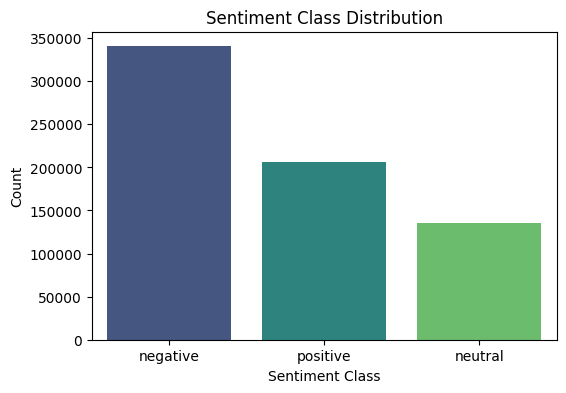

In [ ]:
# SENTIMENT CLASS DISTRIBUTION
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.show()


In [ ]:
(df['sentiment'].value_counts(normalize=True) * 100).round(2)


,proportion
sentiment,
negative,49.91
positive,30.23
neutral,19.86


In [ ]:
# CLEANING FOR ML MODELS (TF-IDF, MNB, RF) ====
!pip install emoji
import re, string, emoji, nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

STOP = set(stopwords.words('english'))
STEM = PorterStemmer()

URL_RE      = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE  = re.compile(r'@\w+')
HASHTAG_RE  = re.compile(r'#')
NUM_RE      = re.compile(r'\d+')
MULTISPACE  = re.compile(r'\s+')
PUNCT_TABLE = str.maketrans('', '', string.punctuation)

def clean_text_ml(text: str) -> str:
    """Aggressive clean for TF-IDF + MNB/RF."""
    if not isinstance(text, str):
        return ""

    t = text.lower()
    t = URL_RE.sub(' ', t)
    t = MENTION_RE.sub(' ', t)
    t = HASHTAG_RE.sub('', t)        # keep tag word
    t = emoji.replace_emoji(t, replace=' ')   # remove emojis
    t = NUM_RE.sub(' ', t)
    t = t.translate(PUNCT_TABLE)

    tokens = nltk.word_tokenize(t)
    tokens = [w for w in tokens if w.isalpha() and w not in STOP]
    tokens = [STEM.stem(w) for w in tokens]   # stemming

    t = ' '.join(tokens)
    t = MULTISPACE.sub(' ', t).strip()

    return t

# Create ML-clean column
df['clean_text_ml'] = df['raw_text'].apply(clean_text_ml)

df[['raw_text','clean_text_ml']].head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,raw_text,clean_text_ml
0,"Entitled, obnoxious, defensive, lying weasel. ...",entitl obnoxi defens lie weasel thing make dec...
1,Thank you and for what you did for the women...,thank women survivor week
2,Knitting (s) &amp; getting ready for January 1...,knit amp get readi januari
3,Yep just like triffeling women weaponized thei...,yep like triffel women weapon poon wonder kama...
4,"No, the President wants to end movement posin...",presid want end movement pose movement


In [ ]:
# TRAINING FOR ML MODELS
from sklearn.model_selection import train_test_split

# Input features (clean text)
X = df['clean_text_ml']

# Target labels (3 classes: positive/negative/neutral)
y = df['sentiment']

# Stratified split keeps class distribution same in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# Check class distribution after split
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)


Train size: 545780
Test size: 136446

Train distribution:
sentiment
negative    49.905090
positive    30.233244
neutral     19.861666
Name: proportion, dtype: float64

Test distribution:
sentiment
negative    49.905457
positive    30.233206
neutral     19.861337
Name: proportion, dtype: float64


[MNB] Accuracy: 0.6969   Macro-F1: 0.6392

              precision    recall  f1-score   support

    negative     0.6812    0.8850    0.7698     68094
     neutral     0.7379    0.3683    0.4913     27100
    positive     0.7214    0.6025    0.6566     41252

    accuracy                         0.6969    136446
   macro avg     0.7135    0.6186    0.6392    136446
weighted avg     0.7046    0.6969    0.6803    136446



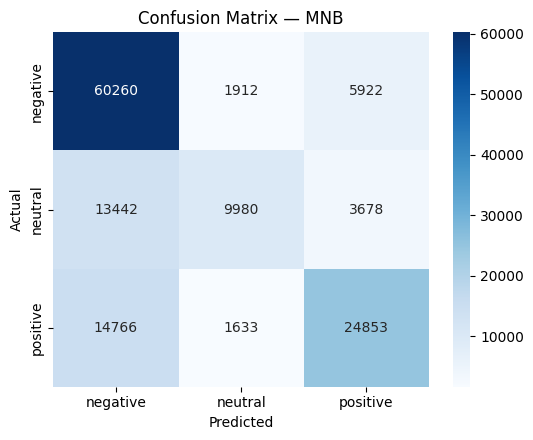

In [ ]:
# === TF-IDF + Multinomial Naive Bayes ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Vectorize
tfidf_mnb = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)
X_train_tfidf_mnb = tfidf_mnb.fit_transform(X_train)
X_test_tfidf_mnb  = tfidf_mnb.transform(X_test)

# Train
mnb = MultinomialNB(alpha=0.1)
mnb.fit(X_train_tfidf_mnb, y_train)

# Predict
y_pred_mnb = mnb.predict(X_test_tfidf_mnb)

# Metrics
acc_mnb = accuracy_score(y_test, y_pred_mnb)
f1_mnb  = f1_score(y_test, y_pred_mnb, average='macro')
print(f"[MNB] Accuracy: {acc_mnb:.4f}   Macro-F1: {f1_mnb:.4f}\n")
print(classification_report(y_test, y_pred_mnb, digits=4))

# Confusion Matrix
labels = sorted(y_test.unique())
cm_mnb = confusion_matrix(y_test, y_pred_mnb, labels=labels)

plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — MNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# Save MNB model
joblib.dump(mnb, "mnb_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf_mnb, "tfidf_mnb.pkl")

print("MNB model saved")

MNB model saved


[RF] Accuracy: 0.6894   Macro-F1: 0.6588
              precision    recall  f1-score   support

    negative     0.6801    0.8483    0.7549     68094
     neutral     0.6939    0.5967    0.6416     27100
    positive     0.7139    0.4882    0.5798     41252

    accuracy                         0.6894    136446
   macro avg     0.6960    0.6444    0.6588    136446
weighted avg     0.6931    0.6894    0.6795    136446



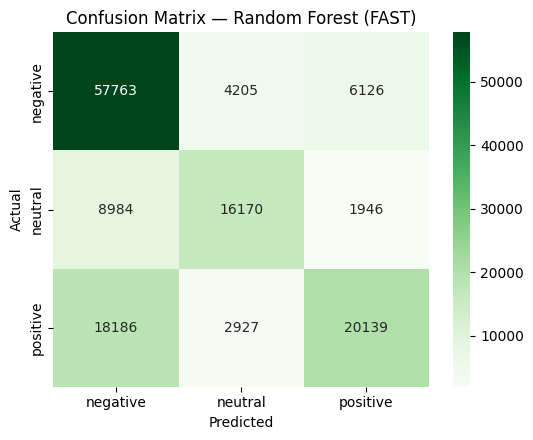

Total RF time: 3490.9s  (USE_SVD=True)


In [ ]:
# === FAST Random Forest on TF-IDF (drop-in replacement) ===
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

t0 = time.time()

# 1) Vectorize (cap features + use float32 to speed up)
tfidf_rf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,              # was 2 — raise to shrink vocab
    max_df=0.9,
    max_features=40000,    # cap vocab size (huge speedup)
    dtype=np.float32
)
X_train_tfidf_rf = tfidf_rf.fit_transform(X_train)
X_test_tfidf_rf  = tfidf_rf.transform(X_test)

# 2) (Optional) SVD to 300 dims → 3–10x faster RF with small accuracy loss
USE_SVD = True
if USE_SVD:
    svd = TruncatedSVD(n_components=300, random_state=42)
    X_train_rf = svd.fit_transform(X_train_tfidf_rf)
    X_test_rf  = svd.transform(X_test_tfidf_rf)
else:
    X_train_rf = X_train_tfidf_rf
    X_test_rf  = X_test_tfidf_rf

# 3) Faster RF config (shallower trees, fewer estimators, balanced)
rf = RandomForestClassifier(
    n_estimators=120,              # was 300
    max_depth=32,                  # limit depth
    max_features='sqrt',           # fewer features per split
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_rf, y_train)

# 4) Predict + metrics
y_pred_rf = rf.predict(X_test_rf)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
print(f"[RF] Accuracy: {acc_rf:.4f}   Macro-F1: {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf, digits=4))

# 5) Confusion matrix
labels = sorted(y_test.unique())
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Random Forest (FAST)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

print(f"Total RF time: {time.time()-t0:.1f}s  (USE_SVD={USE_SVD})")


In [ ]:
import joblib

# Save RF model
joblib.dump(rf, "rf_model.pkl")

# Save RF vectorizer
joblib.dump(tfidf_rf, "tfidf_rf.pkl")

# If you used SVD, save that also
joblib.dump(svd, "svd_rf.pkl")

print("RF model saved")

RF model saved


In [ ]:
# ==== CLEANING FOR DEEP LEARNING (BiLSTM) ====

import re

URL_RE      = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE  = re.compile(r'@\w+')
HASHTAG_RE  = re.compile(r'#')
MULTISPACE  = re.compile(r'\s+')

def clean_text_dl(text: str) -> str:
    """Light clean for DL — KEEP emojis & original word forms."""
    if not isinstance(text, str):
        return ""

    t = text.strip()
    t = URL_RE.sub(' ', t)       # remove URLs
    t = MENTION_RE.sub(' ', t)   # remove @mentions
    t = HASHTAG_RE.sub('', t)    # keep tag word
    t = MULTISPACE.sub(' ', t).strip()

    # NO stemming, NO emoji removal, NO punctuation removal
    return t

# Create DL-clean column
df['clean_text_dl'] = df['raw_text'].apply(clean_text_dl)

df[['raw_text','clean_text_dl']].head()

,raw_text,clean_text_dl
0,"Entitled, obnoxious, defensive, lying weasel. ...","Entitled, obnoxious, defensive, lying weasel. ..."
1,Thank you and for what you did for the women...,Thank you and for what you did for the women a...
2,Knitting (s) &amp; getting ready for January 1...,Knitting (s) &amp; getting ready for January 1...
3,Yep just like triffeling women weaponized thei...,Yep just like triffeling women weaponized thei...
4,"No, the President wants to end movement posin...","No, the President wants to end movement posing..."


In [ ]:
# ==== BiLSTM: data prep ====
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Use the DL-friendly text and the same 3-class labels
X_dl = df['clean_text_dl'].astype(str)
y_lbl = df['sentiment'].map({'negative':0,'neutral':1,'positive':2}).astype(int)

# Stratified split (fresh split for DL; ok if different from ML split)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y_lbl, test_size=0.2, stratify=y_lbl, random_state=42
)

print("Train:", len(X_train_dl), " Test:", len(X_test_dl))
print("Label distribution (train):", pd.Series(y_train_dl).value_counts().to_dict())


Train: 545780  Test: 136446
Label distribution (train): {0: 272372, 2: 165007, 1: 108401}


In [ ]:
# ==== Tokenization & Padding ====
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 50000   # cap vocab size (good for speed)
MAX_LEN   = 60      # sequence length (tweets are short)

tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<UNK>")
tok.fit_on_texts(X_train_dl)

Xtr_seq = tok.texts_to_sequences(X_train_dl)
Xte_seq = tok.texts_to_sequences(X_test_dl)

Xtr_pad = pad_sequences(Xtr_seq, maxlen=MAX_LEN, padding='post', truncating='post')
Xte_pad = pad_sequences(Xte_seq, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tok.word_index) + 1)
vocab_size


50000

In [ ]:
# ==== BiLSTM Model ====
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')   # 3 classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==== Train ====
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    Xtr_pad, y_train_dl,
    validation_split=0.1,
    epochs=5,            # keep small for speed, increase if needed
    batch_size=256,      # adjust based on RAM
    callbacks=[es],
    verbose=1
)


Epoch 1/5
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 845s 434ms/step - accuracy: 0.8643 - loss: 0.3717 - val_accuracy: 0.9151 - val_loss: 0.2529
Epoch 2/5
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 886s 446ms/step - accuracy: 0.9316 - loss: 0.2113 - val_accuracy: 0.9271 - val_loss: 0.2197
Epoch 3/5
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 850s 443ms/step - accuracy: 0.9475 - loss: 0.1650 - val_accuracy: 0.9292 - val_loss: 0.2213
Epoch 4/5
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 843s 433ms/step - accuracy: 0.9572 - loss: 0.1334 - val_accuracy: 0.9270 - val_loss: 0.2421


In [ ]:
model.save("/content/drive/MyDrive/bilstm_model.h5")

import pickle

with open("/content/drive/MyDrive/bilstm_tokenizer.pkl", "wb") as f:
    pickle.dump(tok, f)

In [ ]:
!ls /content/drive/MyDrive

'10th bonafide.pdf'
'10th memo.pdf'
 10thmemo.pdf
 33.gdoc
 aadhar.jpg
 Ace
'Adelli Sravanthi Resume 2.pdf'
'Adobe Scan 12-Dec-2024_1.jpg'
'A.Sravanthi(120420468011) (1).pdf'
'A.Sravanthi(120420468011).pdf'
'Basics of C upto Identifiers (1).gdoc'
'Basics of C upto Identifiers.gdoc'
'Batch1 .jpg'
 bilstm_accuracy_curve.png
 bilstm_confusion_matrix.png
 bilstm_loss_curve.png
 bilstm_model.h5
 bilstm_tokenizer.pkl
 Bonafide.pdf
 Certificates
'CIA II portion.gdoc'
'Class notes.gdoc'
 Classroom
 code.py
'Colab Notebooks'
'Copy of DSA SHEET.gsheet'
'Copy of IS_unit-1.gdoc'
'Copy of IS_unit-1.pdf'
'Copy of Latest_Resume.pdf'
'Copy of PANCard.jpg'
 correction.pdf
'CT20254863483_OL (2) (1).pdf'
'CumulativeGradeReport (1).pdf'
 CumulativeGradeReport.pdf
 DAA.gdoc
 Dam
 DATASTRUCTURESANDALGORITHMSTHRUJAVA.doc
 db.sqlite3
'degree bonafide.pdf'
'degree memo.pdf'
'degree provisional.pdf'
'degree tc.pdf'
'Document 2: Project Proposal.gdoc'
 dup.jpg
 EWS.pdf
'gap certificate.pdf'
 gap.jpg
"I am sharin

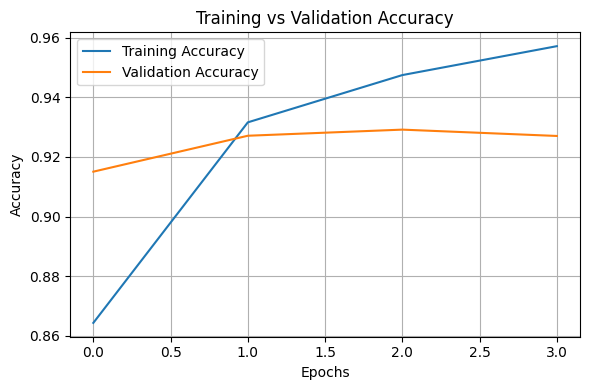

In [ ]:
#Training Accuracy & Validation Accuracy Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bilstm_accuracy_curve.png')
plt.show()

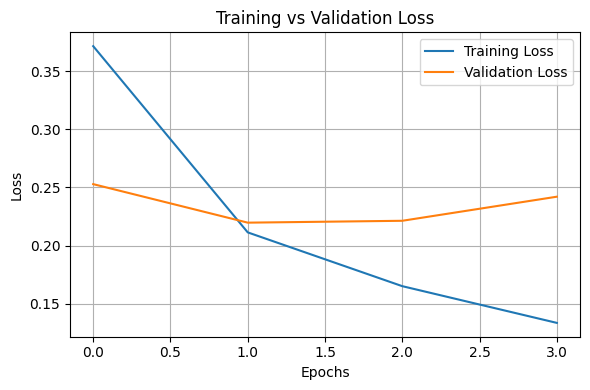

In [ ]:
# Training Loss & Validation Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bilstm_loss_curve.png')
plt.show()

[BiLSTM] Accuracy: 0.9282   Macro-F1: 0.9250

              precision    recall  f1-score   support

    negative     0.9198    0.9610    0.9399     68094
     neutral     0.9703    0.8834    0.9248     27100
    positive     0.9172    0.9034    0.9103     41252

    accuracy                         0.9282    136446
   macro avg     0.9358    0.9159    0.9250    136446
weighted avg     0.9290    0.9282    0.9280    136446



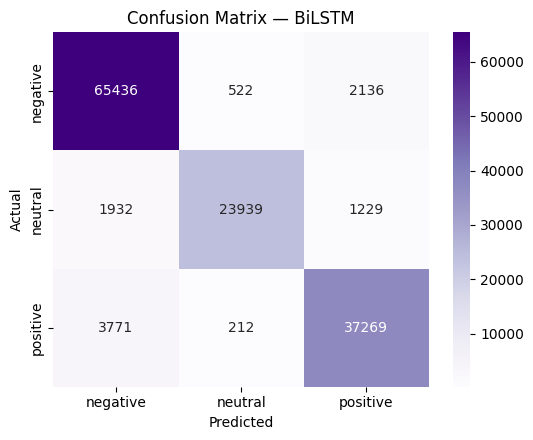

In [ ]:
# ==== Evaluate ====
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_proba = model.predict(Xte_pad, verbose=0)
y_pred_lstm  = np.argmax(y_pred_proba, axis=1)

acc_lstm = accuracy_score(y_test_dl, y_pred_lstm)
f1_lstm  = f1_score(y_test_dl, y_pred_lstm, average='macro')

print(f"[BiLSTM] Accuracy: {acc_lstm:.4f}   Macro-F1: {f1_lstm:.4f}\n")
print(classification_report(y_test_dl, y_pred_lstm, target_names=['negative','neutral','positive'], digits=4))

cm = confusion_matrix(y_test_dl, y_pred_lstm)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("Confusion Matrix — BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
MAX_LEN = 60

def predict_bilstm(text):
    text = clean_text_dl(text)
    seq = tok.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN,
                           padding='post',
                           truncating='post')

    prediction = model.predict(padded, verbose=0)
    predicted_class = np.argmax(prediction, axis=1)[0]

    class_labels = ["negative", "neutral", "positive"]

    print("Input:", text)
    print("Probabilities:", prediction[0])
    print("Predicted:", class_labels[predicted_class])

In [ ]:
predict_bilstm("I feel unsafe walking alone at night")
predict_bilstm("Women deserve respect and safety")
predict_bilstm("The meeting was held yesterday")
predict_bilstm("She was harassed on the road")
predict_bilstm("I am very happy today")

Input: I feel unsafe walking alone at night
Probabilities: [0.9117789  0.07995103 0.00827001]
Predicted: negative
Input: Women deserve respect and safety
Probabilities: [0.00177423 0.00713456 0.99109125]
Predicted: positive
Input: The meeting was held yesterday
Probabilities: [1.0182725e-03 9.9859208e-01 3.8967884e-04]
Predicted: neutral
Input: She was harassed on the road
Probabilities: [9.9471515e-01 5.1503070e-03 1.3459520e-04]
Predicted: negative
Input: I am very happy today
Probabilities: [7.257644e-04 9.132394e-03 9.901418e-01]
Predicted: positive


In [ ]:
predict_bilstm("Women should be respected and protected everywhere")
predict_bilstm("Women are facing harrassment every day")
predict_bilstm("The awareness program was conducted yesterday")
predict_bilstm("Some areas are safe , but women still feel insecure")

Input: Women should be respected and protected everywhere
Probabilities: [0.01165946 0.0117     0.9766406 ]
Predicted: positive
Input: Women are facing harrassment every day
Probabilities: [0.0075826 0.9894784 0.002939 ]
Predicted: neutral
Input: The awareness program was conducted yesterday
Probabilities: [7.636570e-04 9.988807e-01 3.556951e-04]
Predicted: neutral
Input: Some areas are safe , but women still feel insecure
Probabilities: [0.90790004 0.05389744 0.03820253]
Predicted: negative


In [ ]:
predict_bilstm("Women are being abused and threatened every day ")
predict_bilstm("She was assaulted while walking home at night")
predict_bilstm("I am afraid to walk alone because of harrassment.")

Input: Women are being abused and threatened every day
Probabilities: [9.9697578e-01 2.9117232e-03 1.1257593e-04]
Predicted: negative
Input: She was assaulted while walking home at night
Probabilities: [9.9968565e-01 1.7143729e-04 1.4293747e-04]
Predicted: negative
Input: I am afraid to walk alone because of harrassment.
Probabilities: [0.96923906 0.0276547  0.00310626]
Predicted: negative


In [ ]:
from tensorflow.keras.models import load_model
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Load saved model
model = load_model("/content/drive/MyDrive/bilstm_model.h5")

# Load saved tokenizer
with open("/content/drive/MyDrive/bilstm_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Model and tokenizer loaded successfully.")

MAX_LEN = 60

def predict_bilstm(text):

    # Apply the same preprocessing used during training
    text = clean_text_dl(text)

    # Convert text to sequence
    seq = tokenizer.texts_to_sequences([text])

    # Pad sequence
    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    # Predict
    prediction = model.predict(padded, verbose=0)
    predicted_class = np.argmax(prediction, axis=1)[0]

    class_labels = ["negative", "neutral", "positive"]

    print("Input:", text)
    print("Raw Probabilities:", prediction[0])
    print("Predicted Class Index:", predicted_class)
    print("Predicted Label:", class_labels[predicted_class])

Model and tokenizer loaded successfully.


In [ ]:
predict_bilstm("I feel unsafe walking alone at night")
predict_bilstm("Women deserve respect and safety")
predict_bilstm("The meeting was held yesterday")
predict_bilstm("She was harassed on the road")
predict_bilstm("I am very happy today")

Input: I feel unsafe walking alone at night
Raw Probabilities: [0.9117789  0.07995103 0.00827001]
Predicted Class Index: 0
Predicted Label: negative
Input: Women deserve respect and safety
Raw Probabilities: [0.00177423 0.00713456 0.99109125]
Predicted Class Index: 2
Predicted Label: positive
Input: The meeting was held yesterday
Raw Probabilities: [1.0182725e-03 9.9859208e-01 3.8967884e-04]
Predicted Class Index: 1
Predicted Label: neutral
Input: She was harassed on the road
Raw Probabilities: [9.9471515e-01 5.1503070e-03 1.3459520e-04]
Predicted Class Index: 0
Predicted Label: negative
Input: I am very happy today
Raw Probabilities: [7.257644e-04 9.132394e-03 9.901418e-01]
Predicted Class Index: 2
Predicted Label: positive


In [ ]:
predict_bilstm("Women should be respected and protected everywhere")
predict_bilstm("Women are facing harrassment every day")
predict_bilstm("The awareness program was conducted yesterday")
predict_bilstm("Some areas are safe , but women still feel insecure")

Input: Women should be respected and protected everywhere
Raw Probabilities: [0.01165946 0.0117     0.9766406 ]
Predicted Class Index: 2
Predicted Label: positive
Input: Women are facing harrassment every day
Raw Probabilities: [0.0075826 0.9894784 0.002939 ]
Predicted Class Index: 1
Predicted Label: neutral
Input: The awareness program was conducted yesterday
Raw Probabilities: [7.636570e-04 9.988807e-01 3.556951e-04]
Predicted Class Index: 1
Predicted Label: neutral
Input: Some areas are safe , but women still feel insecure
Raw Probabilities: [0.90790004 0.05389744 0.03820253]
Predicted Class Index: 0
Predicted Label: negative


In [ ]:
predict_bilstm("Women are being abused and threatened every day ")
predict_bilstm("She was assaulted while walking home at night")
predict_bilstm("I am afraid to walk alone because of harrassment.")

Input: Women are being abused and threatened every day
Raw Probabilities: [9.9697578e-01 2.9117232e-03 1.1257593e-04]
Predicted Class Index: 0
Predicted Label: negative
Input: She was assaulted while walking home at night
Raw Probabilities: [9.9968565e-01 1.7143729e-04 1.4293747e-04]
Predicted Class Index: 0
Predicted Label: negative
Input: I am afraid to walk alone because of harrassment.
Raw Probabilities: [0.96923906 0.0276547  0.00310626]
Predicted Class Index: 0
Predicted Label: negative


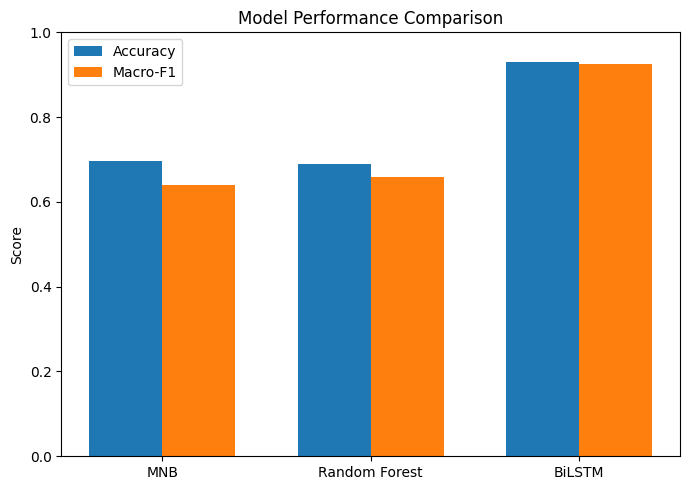

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['MNB', 'Random Forest', 'BiLSTM']

accuracy = [acc_mnb, acc_rf, acc_lstm]
macro_f1 = [f1_mnb, f1_rf, f1_lstm]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, macro_f1, width, label='Macro-F1')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()
plt.ylim(0,1)

plt.tight_layout()
plt.show()